In [1]:
import requests                
from bs4 import BeautifulSoup  
import urllib3                
import pandas as pd
import matplotlib.pyplot as plt


urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = "https://raw.githubusercontent.com/hiksyksy1234/json/main/test.html"

response = requests.get(url, verify=False)

In [13]:
# 받아온 HTML 텍스트(response.text)를 파이썬이 분석할 수 있는 트리 구조(soup)로 변환합니다.
soup = BeautifulSoup(response.text, 'html.parser')

---
1. stocks에 {'종목명': name, '현재가': price, '변동률': change} 형태로 데이터를 저장합니다.

In [3]:
stocks = []

for row in soup.select('.stock-item'):
    name = row.select_one('.name').text

    # 콤마 제거 후 숫자로 변환
    price = int(row.select_one('.price').text.replace(',', ''))
    change = float(row.select_one('.change').text)
    
    stocks.append({'종목명': name, '현재가': price, '변동폭': change})

print(stocks)


[{'종목명': '삼성전자', '현재가': 72500, '변동폭': 2.5}, {'종목명': 'SK하이닉스', '현재가': 141200, '변동폭': 5.1}, {'종목명': 'NAVER', '현재가': 210000, '변동폭': -1.2}, {'종목명': '카카오', '현재가': 49800, '변동폭': 0.8}, {'종목명': 'LG에너지솔루션', '현재가': 385000, '변동폭': -3.5}]


---
2. 위에서 만든 stocks를 DataFrame으로 만듭니다.

In [4]:
df = pd.DataFrame(stocks)
print("--- 전체 주식 데이터 ---")
print(df)

--- 전체 주식 데이터 ---
        종목명     현재가  변동폭
0      삼성전자   72500  2.5
1    SK하이닉스  141200  5.1
2     NAVER  210000 -1.2
3       카카오   49800  0.8
4  LG에너지솔루션  385000 -3.5


---
3. 변동률이 0보다 큰 종목만 추출

In [5]:
rising_stocks = df[df['변동폭'] > 0]
print("\n--- 상승 중인 종목 ---")
print(rising_stocks)


--- 상승 중인 종목 ---
      종목명     현재가  변동폭
0    삼성전자   72500  2.5
1  SK하이닉스  141200  5.1
3     카카오   49800  0.8


---
4. 평균 변동률 계산

In [6]:
avg_change = df['변동폭'].mean()
print(f"\n시장 전체 평균 변동폭: {avg_change:.2f}%")


시장 전체 평균 변동폭: 0.74%


---
5. 데이터 시각화 (Visualization)를 위한 한글 깨짐 방지 설정 (Windows 기준: Malgun Gothic)

In [7]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

---
6. 아래와 같은 그림을 조건에 맞게 그립니다.

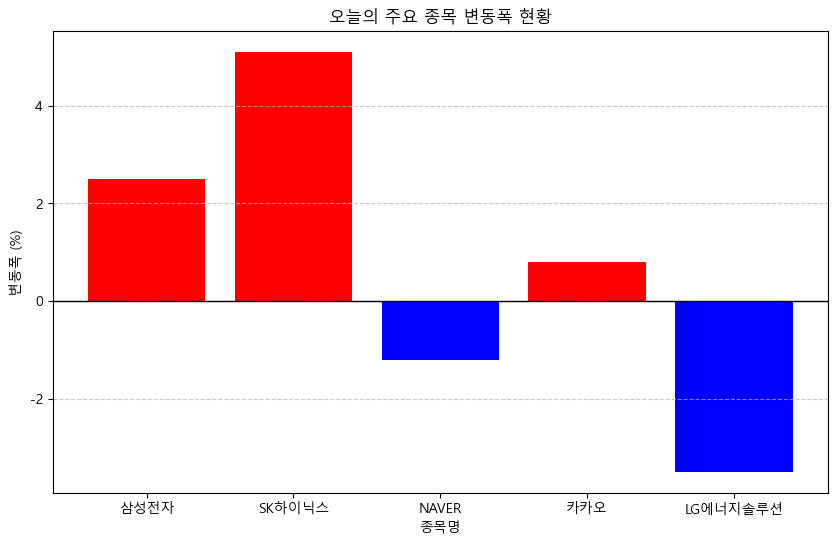

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    df['종목명'],
    df['변동폭'],
    color=['red' if x > 0 else 'blue' for x in df['변동폭']]
)

plt.axhline(0, color='black', linewidth=1)
plt.title('오늘의 주요 종목 변동폭 현황')
plt.xlabel('종목명')
plt.ylabel('변동폭 (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
7. 상승/하락/보합(status) 컬럼 만들기

- 변동률 > 0 : '상승'

- 변동률 < 0 : '하락'

- 변동률 = 0 : '보합'

In [9]:
df["status"] = df["변동폭"].apply(
    lambda x: "상승" if x > 0 else ("하락" if x < 0 else "보합")
)

print(df)

        종목명     현재가  변동폭 status
0      삼성전자   72500  2.5     상승
1    SK하이닉스  141200  5.1     상승
2     NAVER  210000 -1.2     하락
3       카카오   49800  0.8     상승
4  LG에너지솔루션  385000 -3.5     하락


---
8. 변동률 Top 3 종목 출력하기

In [10]:
ans2 = df.sort_values(by='변동폭', ascending=False).head(3)
print(ans2)

      종목명     현재가  변동폭 status
1  SK하이닉스  141200  5.1     상승
0    삼성전자   72500  2.5     상승
3     카카오   49800  0.8     상승


---
9. status별 종목 수 / 평균 변동률

In [11]:
pivot_status = df.pivot_table(
    index="status",
    values="변동폭",
    aggfunc=['count', 'mean']
)
print(pivot_status)

       count  mean
         변동폭   변동폭
status            
상승         3  2.80
하락         2 -2.35


---
10. 변동률이 시장 평균($0.74\%$)보다 낮은 종목만 추출하세요.

In [12]:
market_avg = 0.74
underperforming = df[df['변동폭'] < market_avg]
print("\n--- [시장 평균보다 낮은 종목] ---")
print(underperforming[['종목명', '변동폭']])


--- [시장 평균보다 낮은 종목] ---
        종목명  변동폭
2     NAVER -1.2
4  LG에너지솔루션 -3.5
